<a href="https://colab.research.google.com/github/balamurugan-k006/computer-vision-/blob/main/exp(_3_Wavelet).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[INFO] Generating synthetic image...


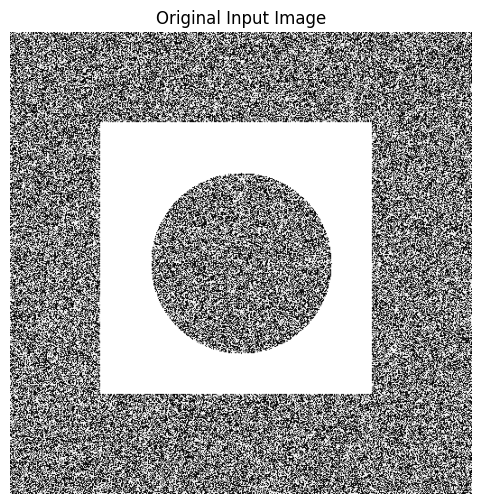

Displaying Decomposition Stages...


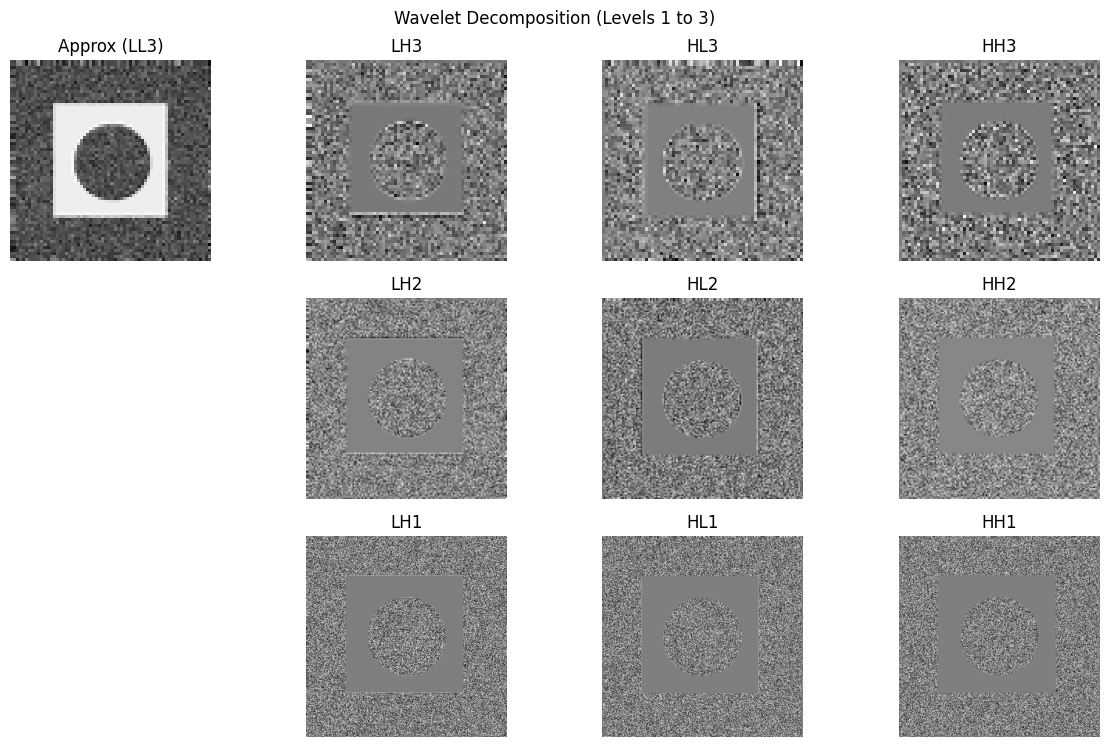


Extracting Features...
FINAL FEATURE VECTOR
                        0
LL3_Energy   7.203338e+09
LL3_Mean     1.208484e+03
LH3_Energy   5.318140e+07
LH3_Entropy  1.141017e+01
LH3_StdDev   1.104900e+02
HL3_Energy   5.619021e+07
HL3_Entropy  1.140848e+01
HL3_StdDev   1.135590e+02
HH3_Energy   4.435131e+07
HH3_Entropy  1.138897e+01
HH3_StdDev   1.008946e+02
LH2_Energy   1.789883e+08
LH2_Entropy  1.332564e+01
LH2_StdDev   1.029113e+02
HL2_Energy   1.757547e+08
HL2_Entropy  1.333104e+01
HL2_StdDev   1.019763e+02
HH2_Energy   1.646269e+08
HH2_Entropy  1.332274e+01
HH2_StdDev   9.869322e+01
LH1_Energy   6.612157e+08
LH1_Entropy  1.530454e+01
LH1_StdDev   1.000541e+02
HL1_Energy   6.552999e+08
HL1_Entropy  1.529933e+01
HL1_StdDev   9.960510e+01
HH1_Energy   6.482250e+08
HH1_Entropy  1.529655e+01
HH1_StdDev   9.906716e+01


In [1]:
import numpy as np
import pywt
import cv2
import matplotlib.pyplot as plt
import pandas as pd

def load_image(path=None):
    if path:
        img = cv2.imread(path, 0)
        if img is None:
            raise ValueError(f"Could not load image at {path}")
    else:
        print("[INFO] Generating synthetic image...")
        img = np.zeros((512, 512), dtype=np.uint8)
        cv2.rectangle(img, (100, 100), (400, 400), 255, -1)
        cv2.circle(img, (256, 256), 100, 0, -1)
        noise = np.random.normal(0, 20, img.shape)
        img = cv2.add(img, noise.astype(np.uint8))
    return img

def visualize_decomposition(coeffs):
    level_count = len(coeffs) - 1
    fig = plt.figure(figsize=(12, 10))
    fig.suptitle(f"Wavelet Decomposition (Levels 1 to {level_count})")

    cA = coeffs[0]
    ax = fig.add_subplot(level_count + 1, 4, 1)
    ax.imshow(cA, cmap='gray')
    ax.set_title(f"Approx (LL{level_count})")
    ax.axis('off')

    for i, details in enumerate(coeffs[1:]):
        level_index = level_count - i
        (cH, cV, cD) = details
        row = i + 1

        ax1 = fig.add_subplot(level_count + 1, 4, row * 4 - 2)
        ax1.imshow(cH, cmap='gray')
        ax1.set_title(f"LH{level_index}")
        ax1.axis('off')

        ax2 = fig.add_subplot(level_count + 1, 4, row * 4 - 1)
        ax2.imshow(cV, cmap='gray')
        ax2.set_title(f"HL{level_index}")
        ax2.axis('off')

        ax3 = fig.add_subplot(level_count + 1, 4, row * 4)
        ax3.imshow(cD, cmap='gray')
        ax3.set_title(f"HH{level_index}")
        ax3.axis('off')

    plt.tight_layout()
    plt.show()

def extract_features(coeffs):
    features = {}

    def calc_entropy(matrix):
        p = np.abs(matrix.flatten())
        p = p / (np.sum(p) + 1e-10)
        p = p[p > 0]
        return -np.sum(p * np.log2(p))

    cA = coeffs[0]
    level = len(coeffs) - 1
    features[f'LL{level}_Energy'] = np.sum(cA**2)
    features[f'LL{level}_Mean'] = np.mean(cA)

    for i, (cH, cV, cD) in enumerate(coeffs[1:]):
        curr_lvl = level - i
        for band, name in zip([cH, cV, cD], ['LH', 'HL', 'HH']):
            features[f'{name}{curr_lvl}_Energy'] = np.sum(band**2)
            features[f'{name}{curr_lvl}_Entropy'] = calc_entropy(band)
            features[f'{name}{curr_lvl}_StdDev'] = np.std(band)

    return pd.DataFrame([features]).T


# ================= MAIN =================
if __name__ == "__main__":

    image_path = None   # 🔹 Put "scan.jpg" if you upload image

    try:
        original_img = load_image(image_path)

        plt.figure(figsize=(6,6))
        plt.imshow(original_img, cmap='gray')
        plt.title("Original Input Image")
        plt.axis('off')
        plt.show()

        coeffs = pywt.wavedec2(original_img, 'db2', level=3)

        print("Displaying Decomposition Stages...")
        visualize_decomposition(coeffs)

        print("\nExtracting Features...")
        feats = extract_features(coeffs)

        print("="*40)
        print("FINAL FEATURE VECTOR")
        print("="*40)
        print(feats)

    except Exception as e:
        print(f"Error: {e}")